# Playing with the `make_moons` dataset in PyTorch


In [15]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.datasets import make_moons


In [16]:
class Timer:
    def __init__(self):
        self.time = None

    def __enter__(self):
        self.time = time.time()

    def __exit__(self, exc_type, exc_value, exc_traceback):
        time_passed = time.time() - self.time
        print(f'** {time_passed:.2f} seconds.')


In [17]:
def plot_decision_boundary(X, y, model, steps=1000, cmap='Paired'):
    cmap = plt.get_cmap(cmap)

    # Define region of interest by data limits
    xmin, xmax = X[:, 0].min() - 1, X[:, 0].max() + 1
    ymin, ymax = X[:, 1].min() - 1, X[:, 1].max() + 1
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)

    # Make predictions across region of interest
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        outputs = model(inputs)
        # Assuming binary classification with one output node or two output nodes
        if outputs.shape[1] > 1:
            _, labels = torch.max(outputs, 1)
        else:
            labels = (outputs > 0.5).int()
        labels = labels.cpu().numpy()

    # Plot decision boundary in region of interest
    z = labels.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, z, cmap=cmap, alpha=0.5)

    # Get predicted labels on training data and plot
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, lw=0)

    return fig, ax


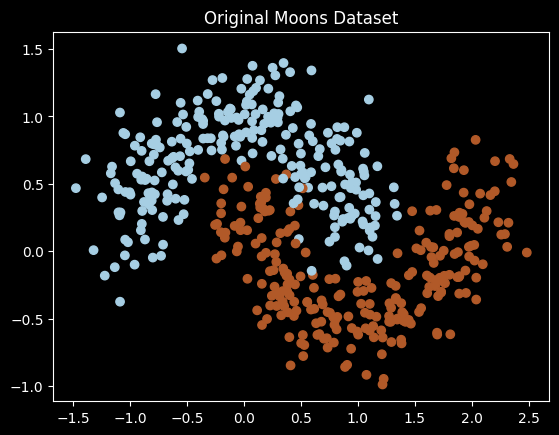

In [18]:
# 1. Generate the dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap='Paired')
plt.title("Original Moons Dataset")
plt.show()


In [19]:
# 2. Define a simple neural network model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleNN()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [20]:
# 3. Training loop
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

print("Starting training...")
with Timer():
    for epoch in range(1001):
        # Forward pass
        model.train()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch [{epoch}/1000], Loss: {loss.item():.4f}")


Starting training...
Epoch [0/1000], Loss: 0.7044
Epoch [200/1000], Loss: 0.0459
Epoch [400/1000], Loss: 0.0289
Epoch [600/1000], Loss: 0.0256
Epoch [800/1000], Loss: 0.0244
Epoch [1000/1000], Loss: 0.0237
** 6.32 seconds.


In [21]:
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    # tqdm creates the progress bar (22/22 [=======])
    progress_bar = tqdm(dataloader, desc="Evaluating", unit="step")

    with torch.no_grad():
        for inputs, targets in progress_bar:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Calculate metrics
            total_loss += loss.item() * inputs.size(0)
            predictions = (outputs > 0.5).float()
            correct += (predictions == targets).sum().item()
            total += targets.size(0)

            # Update the progress bar with live loss and accuracy
            progress_bar.set_postfix(loss=f"{total_loss/total:.4f}",
                                     accuracy=f"{correct/total:.4f}")

    return [total_loss / total, correct / total]

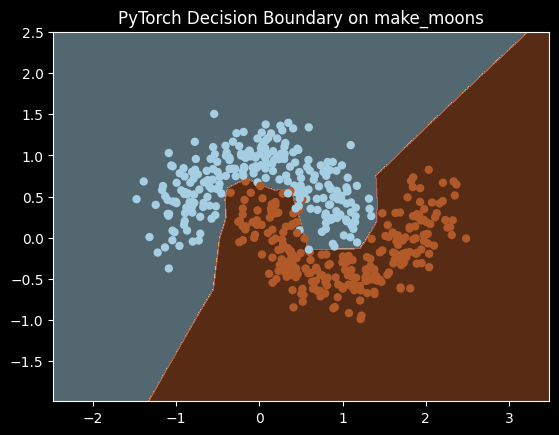

In [22]:
# 4. Plot results
plot_decision_boundary(X, y, model)
plt.title("PyTorch Decision Boundary on make_moons")
plt.show()


In [23]:
model.eval()


SimpleNN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [24]:
# (batch_size, input_features)
summary(model, input_size=(1, 2))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleNN                                 [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 16]                   48
│    └─ReLU: 2-2                         [1, 16]                   --
│    └─Linear: 2-3                       [1, 16]                   272
│    └─ReLU: 2-4                         [1, 16]                   --
│    └─Linear: 2-5                       [1, 1]                    17
│    └─Sigmoid: 2-6                      [1, 1]                    --
Total params: 337
Trainable params: 337
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [25]:
# 1. Set the model to evaluation mode
model.eval()

SimpleNN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [26]:
# Create dataset and loader (assuming batch_size=32)
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32)

In [27]:
results = evaluate(model, dataloader, criterion)
print(results)

Evaluating: 100%|██████████| 16/16 [00:00<00:00, 434.59step/s, accuracy=0.9900, loss=0.0237]

[0.023706978582777084, 0.99]
